## Step 3: The Human-Powered Labeling Machine (Manual Transit Classifier)

This is where science meets *"eh, looks about right to me"* — a semi-automated pipeline that processes every Kepler file from our master list and then asks a human to eyeball the resulting light curve and decide if a transit happened. This is effectively building the **labeled training set** that Notebook 4's neural network will later learn from.

**Why manual labeling?** Transit detection is a supervised learning problem — the CNN in Notebook 4 needs examples of "yes, this is a transit" and "no, this isn't" to learn from. Since we don't have a pre-labeled dataset, a human has to be the label source, at least for this first batch.

**The Algorithm:**
1. **Track what's already labeled** by reading four helper CSVs (`Positive_File.csv`, `Negative_File.csv`, `Uncertain_File.csv`, `Skipped_file.csv`) into a combined `set()` of filenames, so you don't have to judge the same star's life choices twice across multiple sessions.
2. **For each unlabeled file in the master list:**
   - **Open the FITS file** and defensively lower-case all column names (`data.columns.names = [col.lower() for col in ...]`) since FITS column casing can be inconsistent across files.
   - **Check for required columns** (`flux`, `time`) and bail gracefully with a warning if they're missing, rather than crashing the whole loop over one bad file.
   - **Clean the flux**: `np.nan_to_num(flux, nan=0.0, posinf=0.0, neginf=0.0)` — swap `NaN`/`±inf` for `0.0`, because downstream math (and neural nets) do not appreciate infinities or missing values showing up uninvited.
   - **Resize** each frame to a tidy **8×7** grid (same trick as Notebook 2) via `skimage.transform.resize`.
   - **Grab `SAP_FLUX`** if available (Simple Aperture Photometry — Kepler's own pre-computed brightness estimate) as a shortcut alternative to summing pixels manually.
   - **Quality-filter** using the `QUALITY` column when present, keeping only cadences flagged as good (`quality == 0`), and trimming `time`/`resized_flux`/`sap_flux` to match.
3. **Visualize** the result via `create_visualizations()`:
   - An **8×7 heatmap** of the first frame with per-pixel flux values annotated as text — basically a very low-res, numerically-labeled photo of a star doing its star thing.
   - A **raw light curve**: `SAP_FLUX` vs. time if available, otherwise a fallback sum of the resized pixel flux (`np.sum(resized_flux, axis=(1,2))`).
   - A **flattened/detrended curve**: flux is z-score normalized (`normalize_flux()`), then run through `flatten_lc()`, which uses `scipy.signal.savgol_filter` (a smoother, science-y cousin of the rolling median from Notebook 2) with an adaptive window size — it automatically shrinks the window if there isn't enough data, and falls back to a simple median-subtraction if the Savitzky-Golay filter throws an error. Trend and detrended residual are plotted together for a before/after comparison.
4. **ASCII-art the pixel grid** in the terminal too — an 8×7 table of brightness values printed with box-drawing characters — because who doesn't love brightness values formatted like a very boring Sudoku puzzle?
5. **Ask the human** to classify what they're looking at:
   - `1` = Positive transit
   - `2` = Negative transit
   - `3` = Uncertain transit
   - `4` = Skip this dataset
   - `5` = Exit the whole program
   
   Each choice appends the filename to the corresponding CSV via `append_to_csv()`, and updates the in-memory `existing_labels` set so it won't be re-asked about in the same run.
6. **Loop and tally** through the full file list, tracking running counts of Positive/Negative/Uncertain classifications, with an optional "process next file? (yes/no)" prompt between files — giving you an escape hatch if you need a coffee break mid-labeling.

**Output:** Four growing CSV files (`Positive_File.csv`, `Negative_File.csv`, `Uncertain_File.csv`, `Skipped_file.csv`) that together form the labeled dataset consumed directly by Notebook 4.

👀 *TL;DR: this notebook is basically "Tinder, but for exoplanet transits" — swipe right if you see a dip.*

In [1]:
import pandas as pd
import numpy as np
import os
import random
import matplotlib.pyplot as plt
import seaborn as sns
from astropy.io import fits
from skimage.transform import resize
from scipy.signal import savgol_filter
import warnings

warnings.filterwarnings('ignore')

In [2]:
def append_to_csv(filename, csv_path):
    file_exists = os.path.isfile(csv_path)
    mode = 'a' if file_exists else 'w'
    with open(csv_path, mode, newline='') as f:
        if not file_exists:
            f.write("filename\n")
        f.write(f"{filename}\n")

In [3]:
def get_existing_labels():
    label_files = ["Positive_File.csv", "Negative_File.csv", "Uncertain_File.csv", "Skipped_file.csv"]
    existing = set()
    for fname in label_files:
        if os.path.exists(fname):
            try:
                df = pd.read_csv(fname)
                if "filename" in df.columns:
                    existing.update(df["filename"].dropna().tolist())
            except Exception as e:
                print(f"Warning: Could not read {fname}: {e}")
    return existing

In [4]:
def flatten_lc(time, flux, window_length=401, polyorder=2):
    mask = np.isfinite(flux)
    flux_clean = flux[mask]
    time_clean = time[mask]

    if len(flux_clean) < 10:
        print("Warning: Too few valid data points for flattening")
        return np.ones_like(flux), flux

    max_window = min(window_length, len(flux_clean) // 2)
    if max_window < 3:
        max_window = 3
    if max_window % 2 == 0:
        max_window += 1
    window_length = max_window

    try:
        trend_filtered = savgol_filter(flux_clean, window_length, polyorder)
        trend = np.full_like(flux, np.nan)
        detrended = np.full_like(flux, np.nan)
        trend[mask] = np.interp(time_clean, time_clean, trend_filtered)
        detrended_clean = flux_clean - trend[mask] + np.median(flux_clean)
        detrended[mask] = detrended_clean
        return trend, detrended
    except Exception as e:
        print(f"  Error in flattening: {str(e)}")
        median_flux = np.median(flux_clean)
        fallback = np.full_like(flux, np.nan)
        fallback[mask] = flux_clean - median_flux
        return np.full_like(flux, median_flux), fallback

In [5]:
def normalize_flux(flux):
    mask = np.isfinite(flux)
    flux_clean = flux[mask]
    if len(flux_clean) == 0:
        return flux
    normalized = np.full_like(flux, np.nan)
    normalized[mask] = (flux_clean - np.mean(flux_clean)) / np.std(flux_clean)
    return normalized

In [6]:
def process_kepler_file(filename):
    try:
        hdulist = fits.open(filename)
        data = hdulist[1].data
        data.columns.names = [col.lower() for col in data.columns.names]
        print(f"Available columns: {data.columns.names}")
        if 'flux' not in data.columns.names:
            print(f"Warning: 'flux' column not found in {filename}")
            return None
        if 'time' not in data.columns.names:
            print(f"Warning: 'time' column not found in {filename}")
            return None
        flux = data['flux']
        time = data['time']
        quality = data['quality'] if 'quality' in data.columns.names else None
        sap_flux = data['sap_flux'] if 'sap_flux' in data.columns.names else None
        flux = np.nan_to_num(flux, nan=0.0, posinf=0.0, neginf=0.0)
        resized_flux = []
        for img in flux:
            img_resized = resize(img, (8, 7), mode='reflect', preserve_range=True)
            resized_flux.append(img_resized)
        resized_flux = np.array(resized_flux)
        print(f"Original shape: {flux.shape}")
        print(f"Resized shape: {resized_flux.shape}")
        if sap_flux is not None:
            sap_flux = np.nan_to_num(sap_flux, nan=0.0, posinf=0.0, neginf=0.0)
            print(f"SAP_FLUX shape: {sap_flux.shape}")
        else:
            print("SAP_FLUX not available")
        if quality is not None:
            mask = quality == 0
            time = time[mask]
            resized_flux = resized_flux[mask]
            if sap_flux is not None:
                sap_flux = sap_flux[mask]
            print(f"Filtered by quality: {np.sum(mask)} good points out of {len(quality)}")
        return {
            'time': time,
            'resized_flux': resized_flux,
            'sap_flux': sap_flux,
            'filename': filename
        }
    except Exception as e:
        print(f"Error processing {filename}: {str(e)}")
        import traceback
        traceback.print_exc()
        return None

In [7]:
def create_visualizations(data_dict):
    time = data_dict['time']
    resized_flux = data_dict['resized_flux']
    sap_flux = data_dict['sap_flux']
    plt.figure(figsize=(6,5))
    im = plt.imshow(resized_flux[0], cmap='hot', aspect='auto', interpolation='nearest')
    plt.colorbar(im, label='Flux', shrink=0.8)
    plt.title(f'8x7 Pixel Image\n{os.path.basename(data_dict["filename"])}')
    plt.xlabel('X Pixel')
    plt.ylabel('Y Pixel')
    for i in range(8):
        for j in range(7):
            plt.text(j, i, f'{resized_flux[0,i,j]:.0f}', ha='center', va='center', color='white', fontsize=6)
    plt.tight_layout()
    plt.show()
    if sap_flux is not None:
        sap_flux_clean = np.nan_to_num(sap_flux, nan=0.0)
        plt.figure(figsize=(14,6))
        plt.plot(time, sap_flux_clean, 'b-', linewidth=0.5)
        plt.xlabel('Time (BJD)')
        plt.ylabel('SAP Flux (e-/s)')
        plt.title(f'SAP Flux vs Time\n{os.path.basename(data_dict["filename"])}')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
    else:
        print("No SAP_FLUX, using sum of pixels")
        flux_sum = np.sum(resized_flux, axis=(1,2))
        plt.figure(figsize=(14,6))
        plt.plot(time, flux_sum, 'b-', linewidth=0.5)
        plt.xlabel('Time (BJD)')
        plt.ylabel('Sum of Pixel Flux')
        plt.title(f'Sum of Pixel Flux vs Time\n{os.path.basename(data_dict["filename"])}')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
        sap_flux = flux_sum
    if sap_flux is not None and len(sap_flux) > 10:
        sap_flux_clean = np.nan_to_num(sap_flux, nan=0.0)
        sap_flux_norm = normalize_flux(sap_flux_clean)
        mask = np.isfinite(sap_flux_norm)
        if np.sum(mask) >= 10:
            time_clean = time[mask]
            sap_flux_norm_clean = sap_flux_norm[mask]
            trend, detrended = flatten_lc(time_clean, sap_flux_norm_clean, window_length=401, polyorder=2)
            fig, (ax1, ax2) = plt.subplots(2,1, figsize=(14,10))
            ax1.plot(time_clean, sap_flux_norm_clean, 'b-', lw=0.5, label='Normalized Flux')
            ax1.plot(time_clean, trend, 'r-', lw=2, label='Trend')
            ax1.set_xlabel('Time (BJD)')
            ax1.set_ylabel('Normalized Flux')
            ax1.set_title('Normalized Flux with Trend')
            ax1.grid(True, alpha=0.3)
            ax1.legend()
            ax2.plot(time_clean, detrended, 'g-', lw=0.5, label='Detrended')
            ax2.axhline(y=np.median(detrended), color='r', linestyle='--', label=f'Median: {np.median(detrended):.3f}')
            ax2.set_xlabel('Time (BJD)')
            ax2.set_ylabel('Detrended Flux')
            ax2.set_title('Detrended Light Curve')
            ax2.grid(True, alpha=0.3)
            ax2.legend()
            plt.tight_layout()
            plt.show()

In [8]:
def main():
    csv_filename = "names.fitz.gz.csv"
    if not os.path.exists(csv_filename):
        print(f"Error: CSV file '{csv_filename}' not found!")
        return
    df = pd.read_csv(csv_filename)
    file_names = df["name"].tolist()
    print(f"Found {len(file_names)} files to process")

    existing_labels = get_existing_labels()
    if existing_labels:
        print(f"Found {len(existing_labels)} already classified files. They will be skipped.")

    positive_datasets = []
    uncertain_datasets = []
    negative_datasets = []

    for i, filename in enumerate(file_names):
        if filename in existing_labels:
            print(f"\nFile {i+1}/{len(file_names)}: {filename} - already classified, skipping.")
            continue

        print(f"\nProcessing file {i+1}/{len(file_names)}: {filename}")
        if not os.path.exists(filename):
            print(f"Warning: File '{filename}' not found!")
            continue
        data_dict = process_kepler_file(filename)
        if data_dict is None:
            continue

        print("Generating visualizations...")
        create_visualizations(data_dict)
        print("8x7 Pixel Image (First frame):")
        print("\n")
        for r in range(8):
            row = "│ "
            for c in range(7):
                val = data_dict['resized_flux'][0, r, c]
                row += f"{val:6.0f} "
            row += "│"
            print(row)
        print('\n')

        while True:
            print("Classification Options:")
            print("1 = Positive transit")
            print("2 = Negative transit")
            print("3 = Uncertain transit")
            print("4 = Skip this dataset")
            print("5 = Exit program (stop processing)")

            choice = input("Enter your choice (1-5): ").strip()

            if choice == '1':
                print("Marked as POSITIVE.")
                append_to_csv(filename, "Positive_File.csv")
                positive_datasets.append({'filename': filename, 'data': data_dict, 'label': 1})
                existing_labels.add(filename)  # update set to avoid re-processing within same run
                break
            elif choice == '2':
                print("Marked as NEGATIVE.")
                append_to_csv(filename, "Negative_File.csv")
                negative_datasets.append({'filename': filename, 'data': data_dict, 'label': 0})
                existing_labels.add(filename)
                break
            elif choice == '3':
                print("Marked as UNCERTAIN.")
                append_to_csv(filename, "Uncertain_File.csv")
                uncertain_datasets.append({'filename': filename, 'data': data_dict, 'label': 1})
                existing_labels.add(filename)
                break
            elif choice == '4':
                print("Skipped.")
                append_to_csv(filename, "Skipped_file.csv")
                existing_labels.add(filename)
                break
            elif choice == '5':
                print("Exiting program.")
                print(f"Final counts: Pos={len(positive_datasets)}, Unc={len(uncertain_datasets)}, Neg={len(negative_datasets)}")
                return
            else:
                print("Invalid choice.")
            print('\n')

        print(f"Current Stats: Pos={len(positive_datasets)}, Unc={len(uncertain_datasets)}, Neg={len(negative_datasets)}")

        if i < len(file_names)-1:
            cont = input("Process next file? (yes/no): ").strip().lower()
            if cont not in ['yes','y']:
                print("Exiting program.")
                break

    print("All files processed!")
    print(f"Final counts: Pos={len(positive_datasets)}, Unc={len(uncertain_datasets)}, Neg={len(negative_datasets)}")

Found 35 files to process
Found 28 already classified files. They will be skipped.

File 1/35: kplr005780885-2009131105131_lpd-targ.fits.gz - already classified, skipping.

File 2/35: kplr005780885-2009166043257_lpd-targ.fits.gz - already classified, skipping.

File 3/35: kplr005780885-2009291181958_spd-targ.fits.gz - already classified, skipping.

File 4/35: kplr005780885-2010326094124_spd-targ.fits.gz - already classified, skipping.

File 5/35: kplr005780885-2011024051157_spd-targ.fits.gz - already classified, skipping.

File 6/35: kplr005780885-2011053090032_spd-targ.fits.gz - already classified, skipping.

File 7/35: kplr005780885-2011073133259_spd-targ.fits.gz - already classified, skipping.

File 8/35: kplr005780885-2011177032512_lpd-targ.fits.gz - already classified, skipping.

File 9/35: kplr008191672-2010140023957_spd-targ.fits.gz - already classified, skipping.

File 10/35: kplr009651668-2009166043257_lpd-targ.fits.gz - already classified, skipping.

File 11/35: kplr009651668

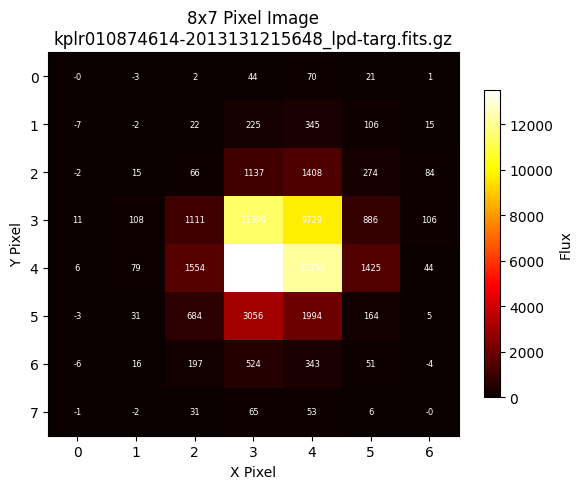

No SAP_FLUX, using sum of pixels


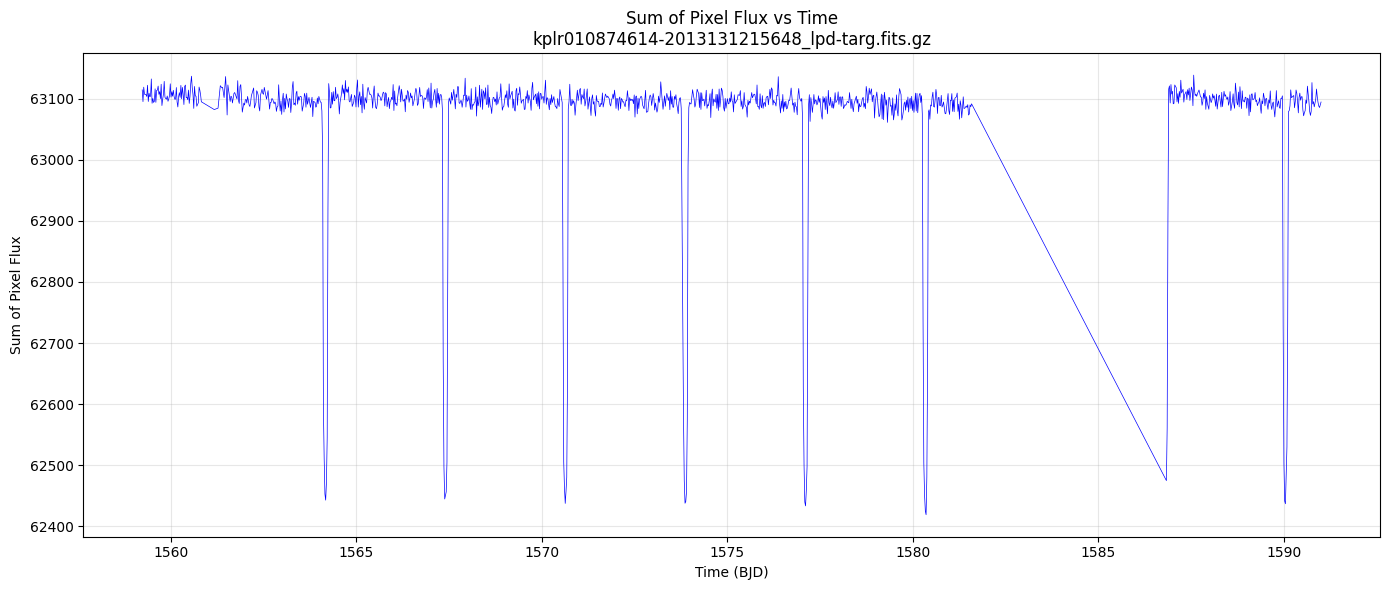

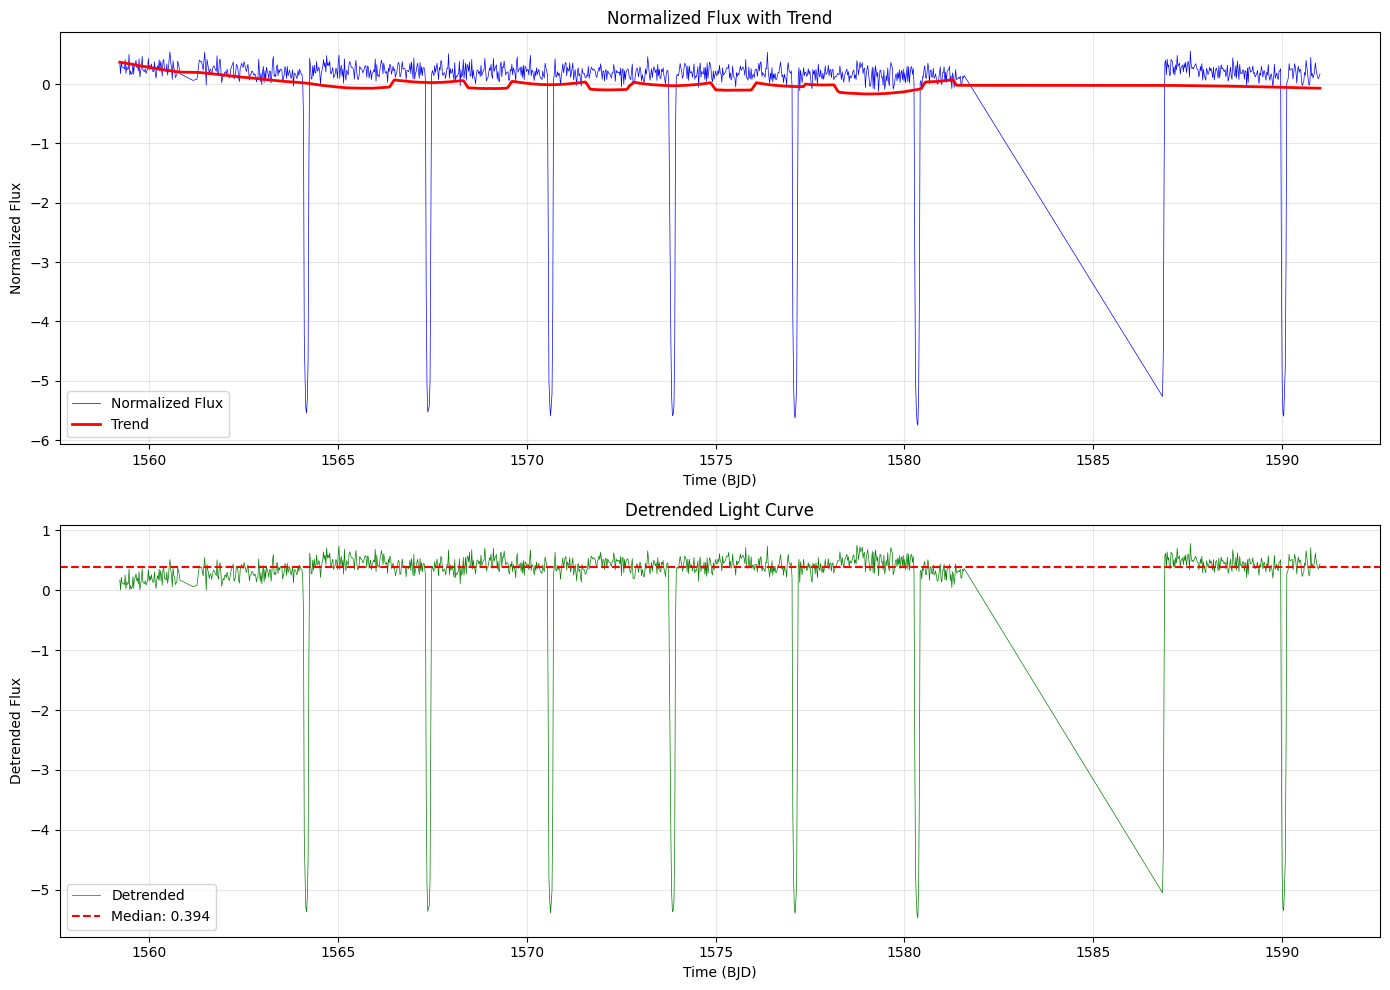

8x7 Pixel Image (First frame):


│     -0     -3      2     44     70     21      1 │
│     -7     -2     22    225    345    106     15 │
│     -2     15     66   1137   1408    274     84 │
│     11    108   1111  11399   9729    886    106 │
│      6     79   1554  13477  12154   1425     44 │
│     -3     31    684   3056   1994    164      5 │
│     -6     16    197    524    343     51     -4 │
│     -1     -2     31     65     53      6     -0 │


Classification Options:
1 = Positive transit
2 = Negative transit
3 = Uncertain transit
4 = Skip this dataset
5 = Exit program (stop processing)


Enter your choice (1-5):  1


Marked as POSITIVE.
Current Stats: Pos=1, Unc=0, Neg=0


Process next file? (yes/no):  y



File 18/35: kplr011446443-2009131105131_lpd-targ.fits.gz - already classified, skipping.

Processing file 19/35: kplr011446443-2009131110544_spd-targ.fits.gz
Available columns: ['time', 'timecorr', 'cadenceno', 'raw_cnts', 'flux', 'flux_err', 'flux_bkg', 'flux_bkg_err', 'cosmic_rays', 'quality', 'pos_corr1', 'pos_corr2', 'rb_level']
Original shape: (14280, 9, 8)
Resized shape: (14280, 8, 7)
SAP_FLUX not available
Filtered by quality: 13634 good points out of 14280
Generating visualizations...


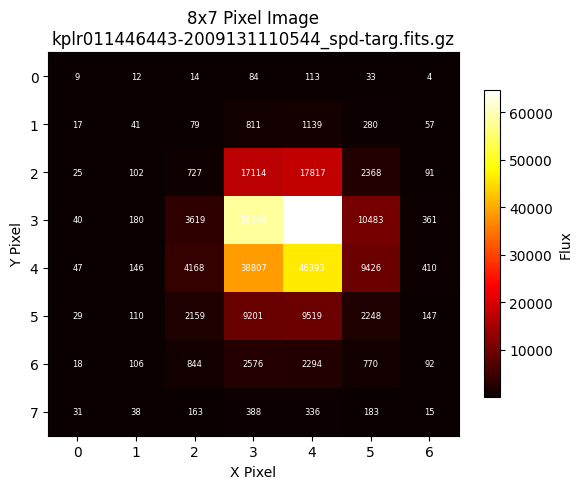

No SAP_FLUX, using sum of pixels


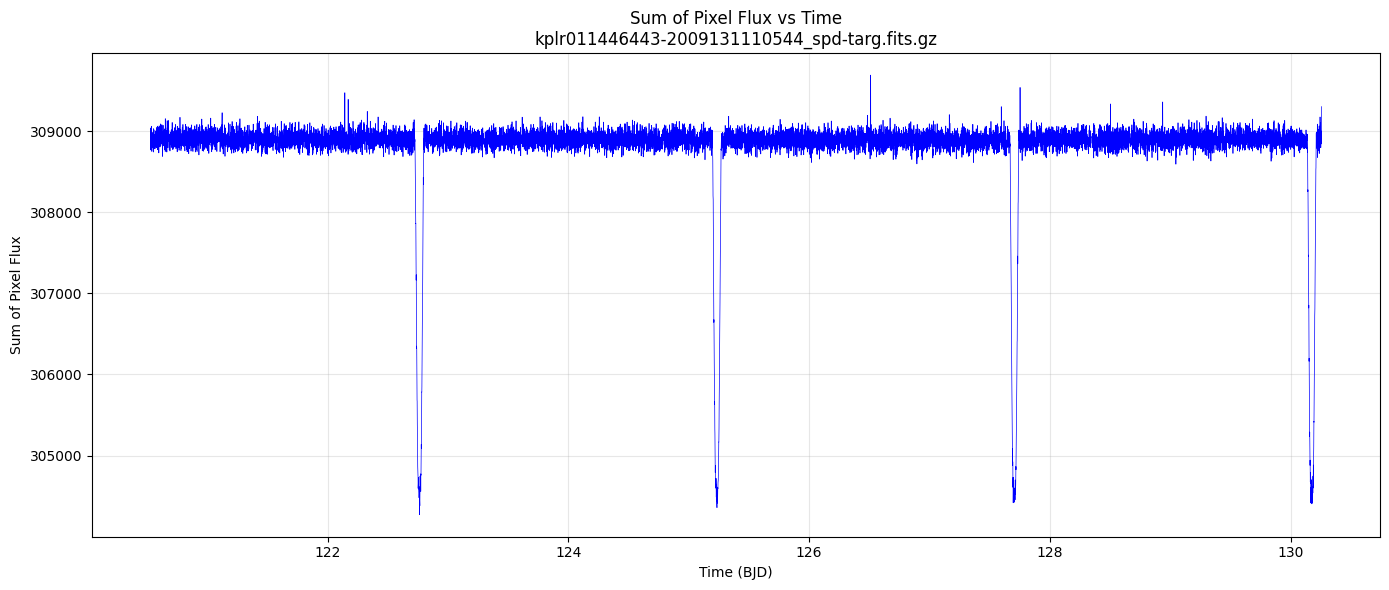

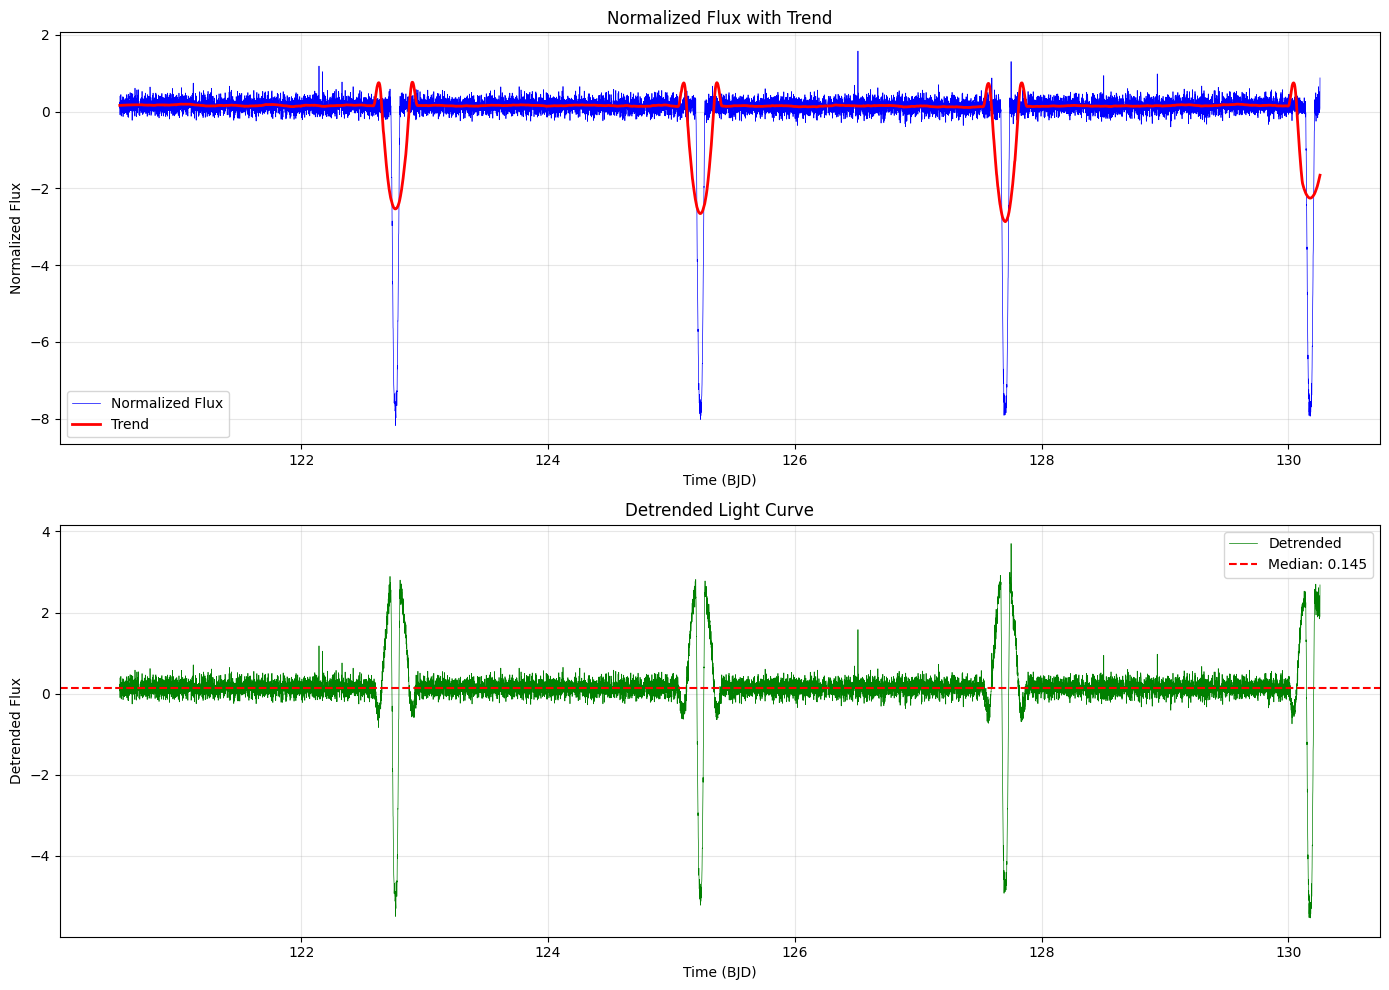

8x7 Pixel Image (First frame):


│      9     12     14     84    113     33      4 │
│     17     41     79    811   1139    280     57 │
│     25    102    727  17114  17817   2368     91 │
│     40    180   3619  58088  64564  10483    361 │
│     47    146   4168  38807  46393   9426    410 │
│     29    110   2159   9201   9519   2248    147 │
│     18    106    844   2576   2294    770     92 │
│     31     38    163    388    336    183     15 │


Classification Options:
1 = Positive transit
2 = Negative transit
3 = Uncertain transit
4 = Skip this dataset
5 = Exit program (stop processing)


Enter your choice (1-5):  4


Skipped.
Current Stats: Pos=1, Unc=0, Neg=0


Process next file? (yes/no):  y



File 20/35: kplr011904151-2009131105131_lpd-targ.fits.gz - already classified, skipping.

File 21/35: kplr011904151-2009166043257_lpd-targ.fits.gz - already classified, skipping.

File 22/35: kplr011904151-2009231120729_spd-targ.fits.gz - already classified, skipping.

File 23/35: kplr011904151-2009259160929_lpd-targ.fits.gz - already classified, skipping.

File 24/35: kplr011904151-2009291181958_spd-targ.fits.gz - already classified, skipping.

File 25/35: kplr011904151-2009350155506_lpd-targ.fits.gz - already classified, skipping.

Processing file 26/35: kplr011904151-2010009091648_lpd-targ.fits.gz
Available columns: ['time', 'timecorr', 'cadenceno', 'raw_cnts', 'flux', 'flux_err', 'flux_bkg', 'flux_bkg_err', 'cosmic_rays', 'quality', 'pos_corr1', 'pos_corr2', 'rb_level']
Original shape: (1021, 9, 7)
Resized shape: (1021, 8, 7)
SAP_FLUX not available
Filtered by quality: 926 good points out of 1021
Generating visualizations...


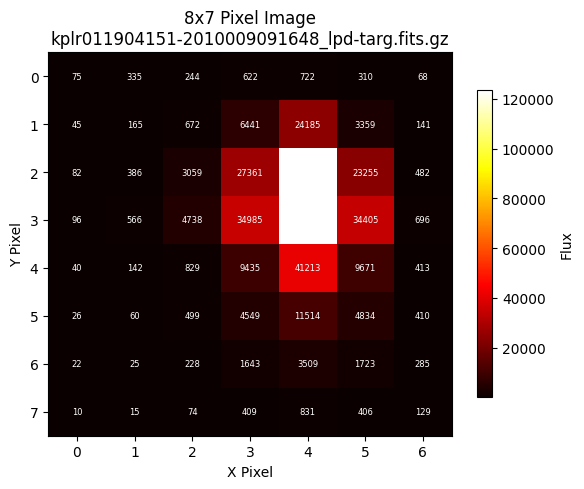

No SAP_FLUX, using sum of pixels


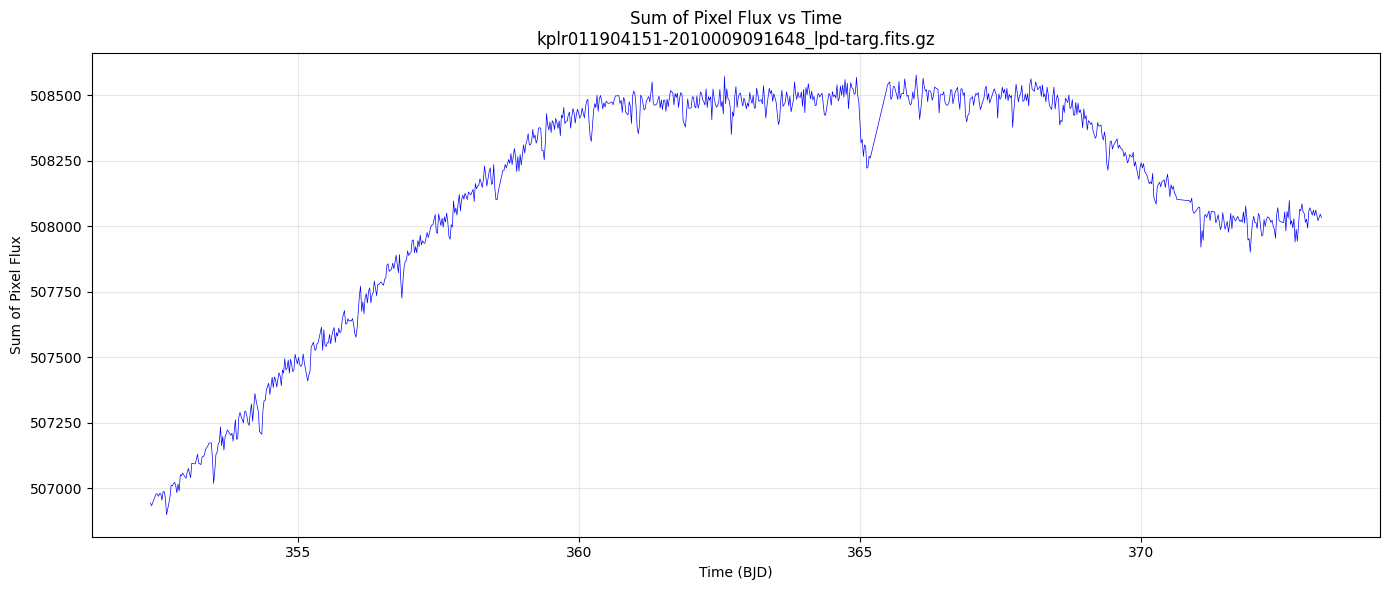

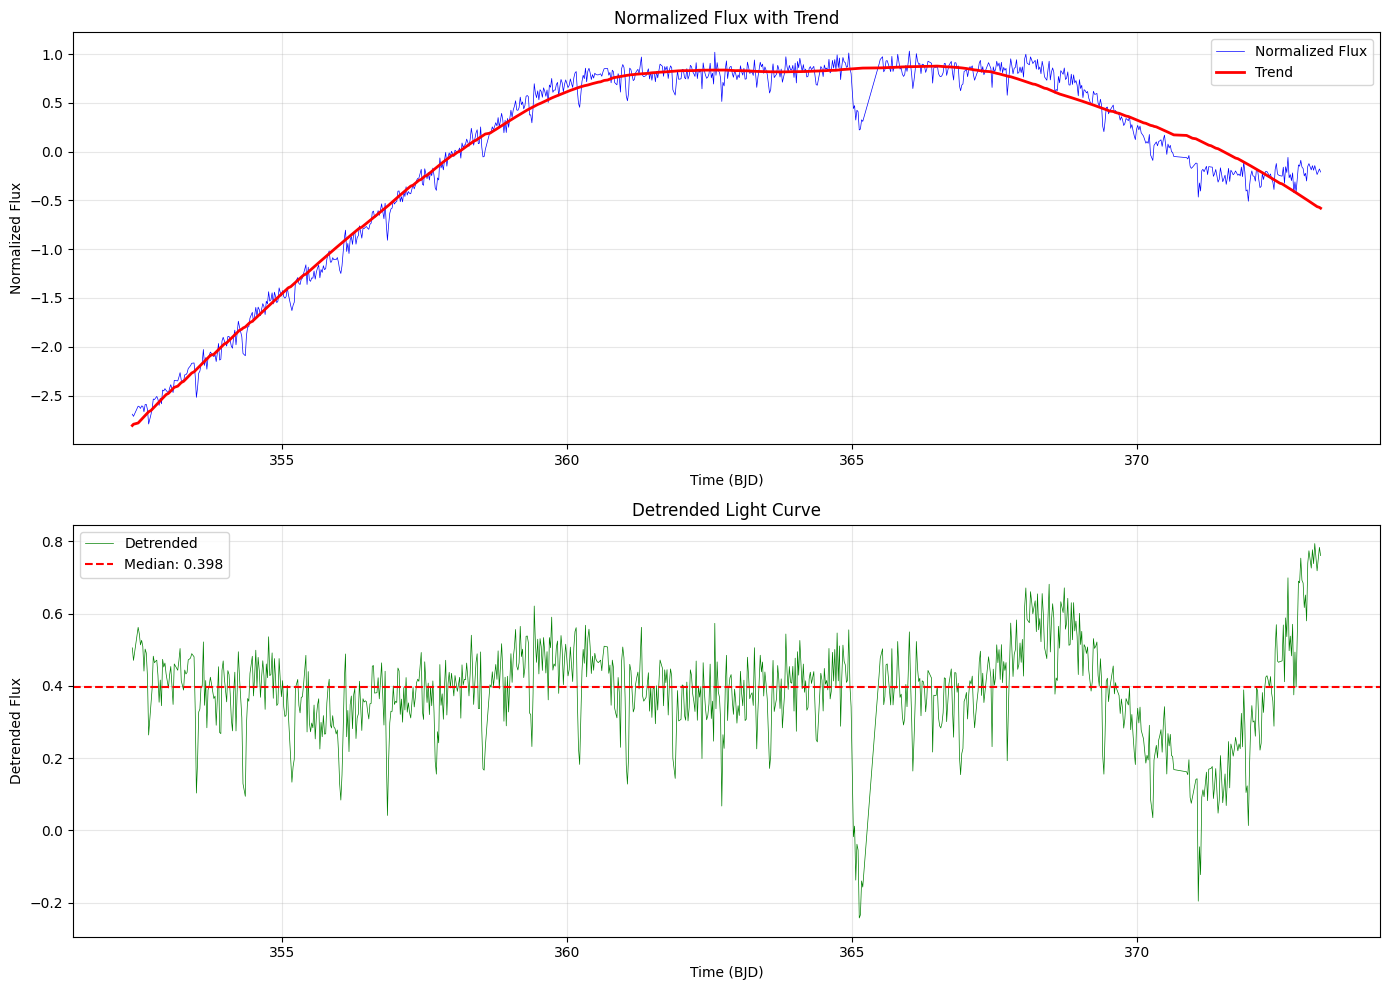

8x7 Pixel Image (First frame):


│     75    335    244    622    722    310     68 │
│     45    165    672   6441  24185   3359    141 │
│     82    386   3059  27361 123111  23255    482 │
│     96    566   4738  34985 123393  34405    696 │
│     40    142    829   9435  41213   9671    413 │
│     26     60    499   4549  11514   4834    410 │
│     22     25    228   1643   3509   1723    285 │
│     10     15     74    409    831    406    129 │


Classification Options:
1 = Positive transit
2 = Negative transit
3 = Uncertain transit
4 = Skip this dataset
5 = Exit program (stop processing)


Enter your choice (1-5):  2


Marked as NEGATIVE.
Current Stats: Pos=1, Unc=0, Neg=1


Process next file? (yes/no):  y



File 27/35: kplr011904151-2010111051353_spd-targ.fits.gz - already classified, skipping.

File 28/35: kplr011904151-2010174090439_spd-targ.fits.gz - already classified, skipping.

File 29/35: kplr011904151-2010234115140_spd-targ.fits.gz - already classified, skipping.

File 30/35: kplr011904151-2010265121752_lpd-targ.fits.gz - already classified, skipping.

File 31/35: kplr011904151-2013131215648_spd-targ.fits.gz - already classified, skipping.

Processing file 32/35: kplr001430163-2009131105131_lpd-targ.fits.gz
Available columns: ['time', 'timecorr', 'cadenceno', 'raw_cnts', 'flux', 'flux_err', 'flux_bkg', 'flux_bkg_err', 'cosmic_rays', 'quality', 'pos_corr1', 'pos_corr2', 'rb_level']
Original shape: (476, 15, 15)
Resized shape: (476, 8, 7)
SAP_FLUX not available
Filtered by quality: 400 good points out of 476
Generating visualizations...


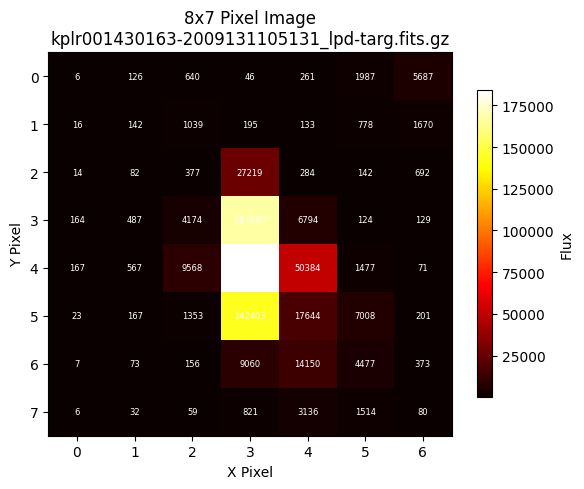

No SAP_FLUX, using sum of pixels


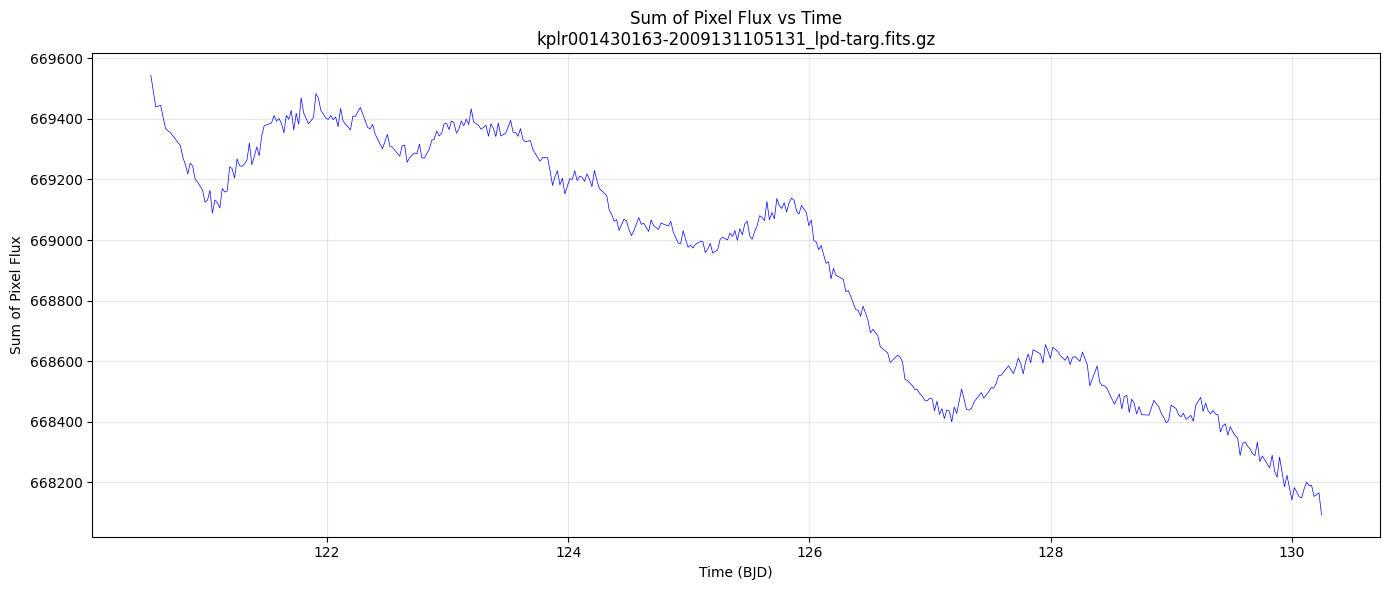

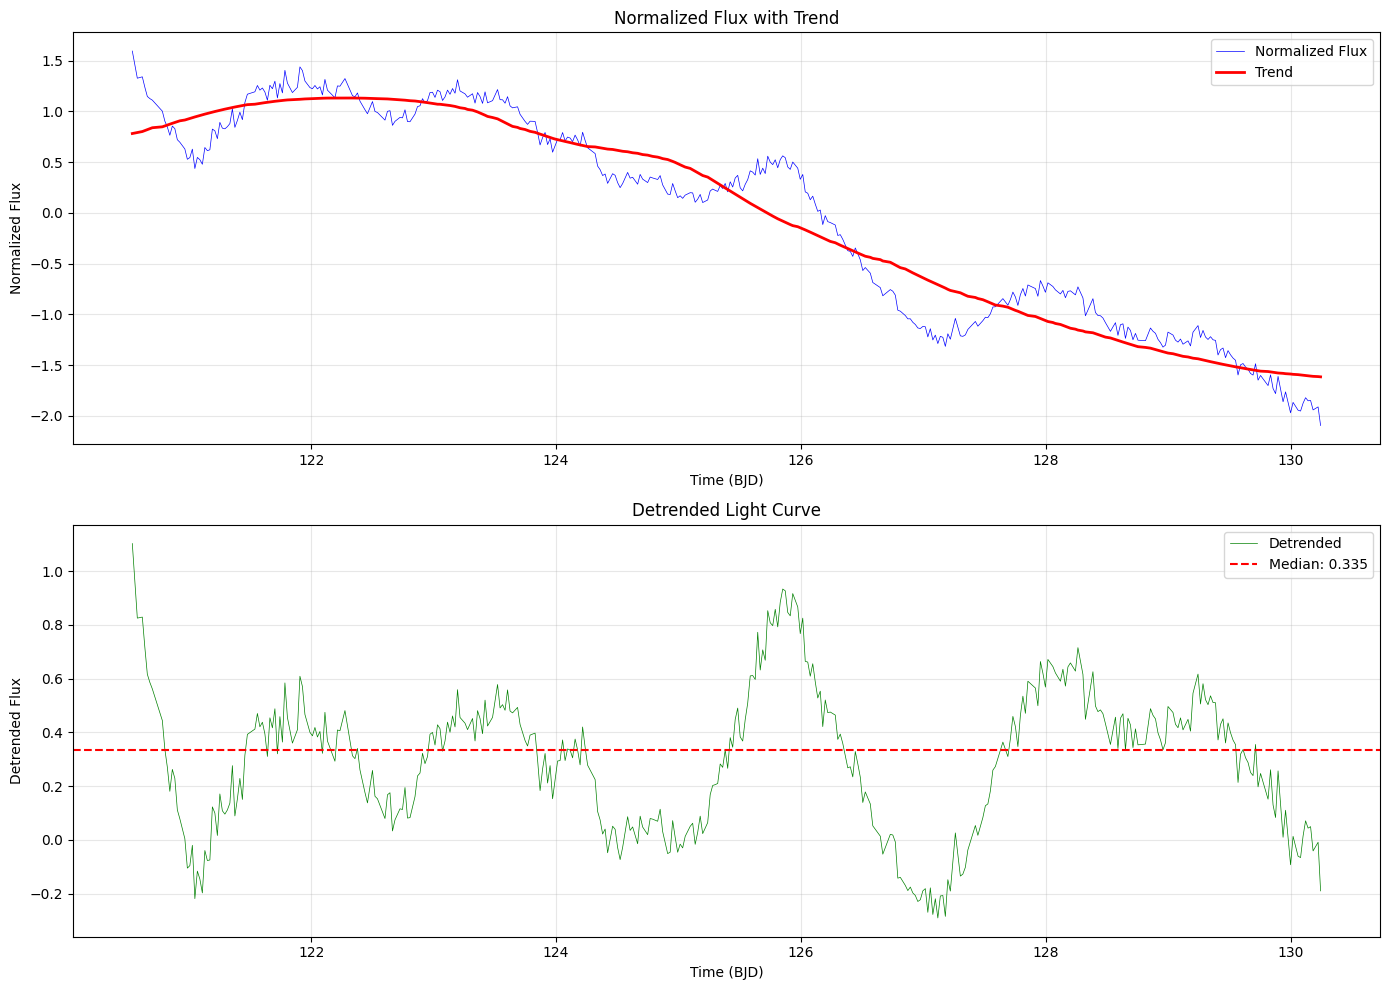

8x7 Pixel Image (First frame):


│      6    126    640     46    261   1987   5687 │
│     16    142   1039    195    133    778   1670 │
│     14     82    377  27219    284    142    692 │
│    164    487   4174 167295   6794    124    129 │
│    167    567   9568 183865  50384   1477     71 │
│     23    167   1353 142403  17644   7008    201 │
│      7     73    156   9060  14150   4477    373 │
│      6     32     59    821   3136   1514     80 │


Classification Options:
1 = Positive transit
2 = Negative transit
3 = Uncertain transit
4 = Skip this dataset
5 = Exit program (stop processing)


Enter your choice (1-5):  2


Marked as NEGATIVE.
Current Stats: Pos=1, Unc=0, Neg=2


Process next file? (yes/no):  y



Processing file 33/35: kplr001430163-2010174090439_spd-targ.fits.gz
Available columns: ['time', 'timecorr', 'cadenceno', 'raw_cnts', 'flux', 'flux_err', 'flux_bkg', 'flux_bkg_err', 'cosmic_rays', 'quality', 'pos_corr1', 'pos_corr2', 'rb_level']
Original shape: (49290, 12, 11)
Resized shape: (49290, 8, 7)
SAP_FLUX not available
Filtered by quality: 44124 good points out of 49290
Generating visualizations...


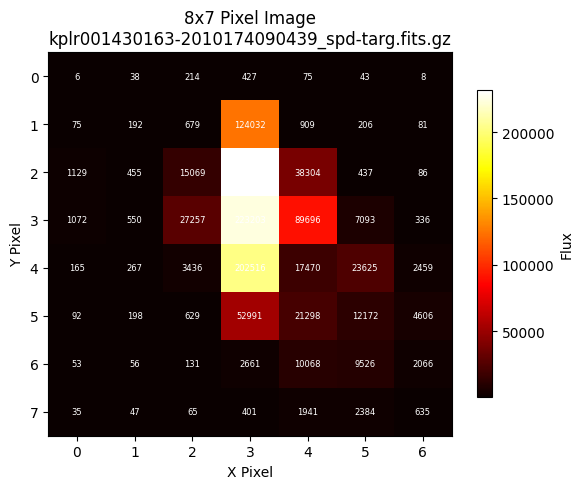

No SAP_FLUX, using sum of pixels


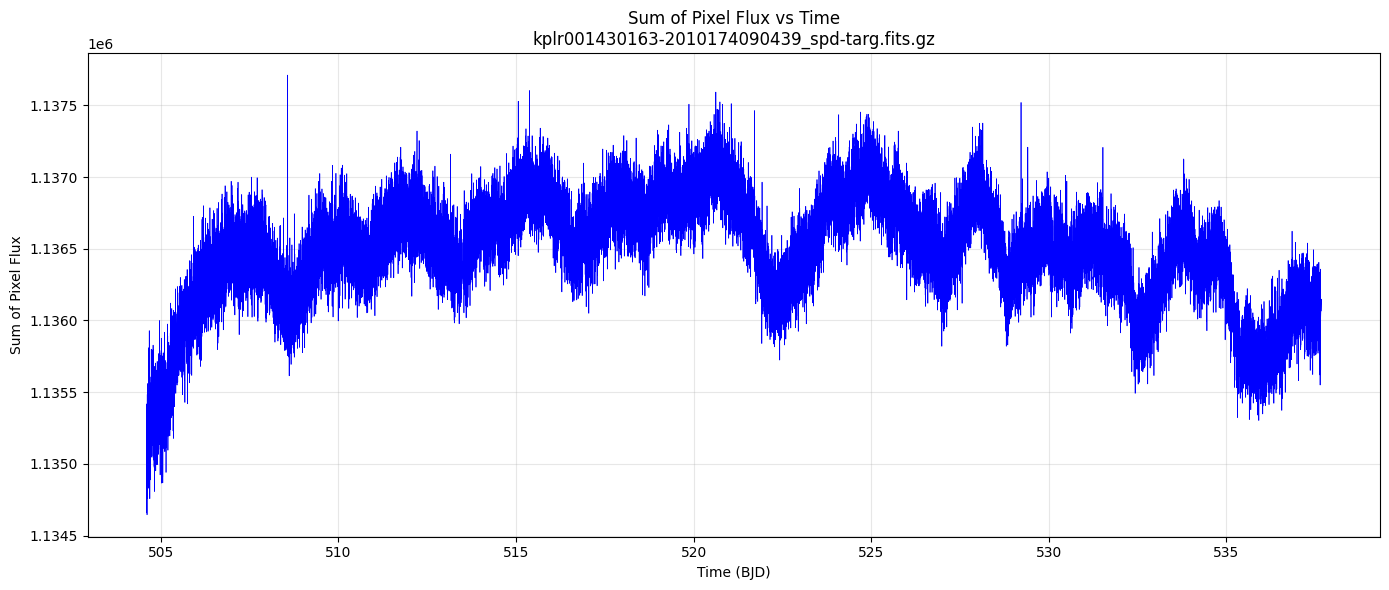

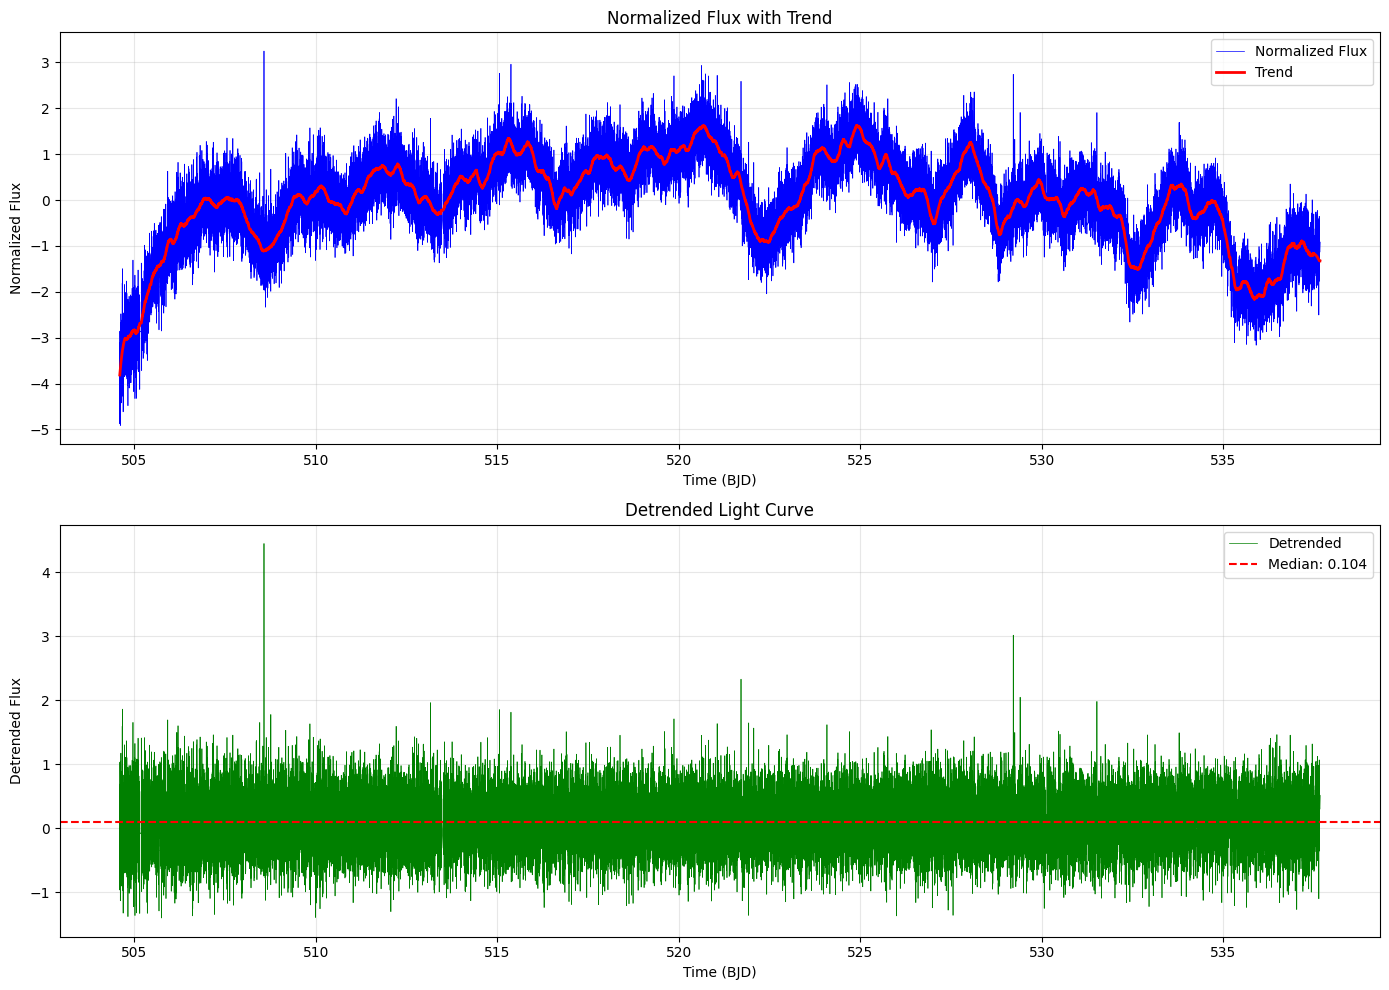

8x7 Pixel Image (First frame):


│      6     38    214    427     75     43      8 │
│     75    192    679 124032    909    206     81 │
│   1129    455  15069 231285  38304    437     86 │
│   1072    550  27257 223203  89696   7093    336 │
│    165    267   3436 202516  17470  23625   2459 │
│     92    198    629  52991  21298  12172   4606 │
│     53     56    131   2661  10068   9526   2066 │
│     35     47     65    401   1941   2384    635 │


Classification Options:
1 = Positive transit
2 = Negative transit
3 = Uncertain transit
4 = Skip this dataset
5 = Exit program (stop processing)


Enter your choice (1-5):  2


Marked as NEGATIVE.
Current Stats: Pos=1, Unc=0, Neg=3


Process next file? (yes/no):  y



Processing file 34/35: kplr002571238-2013131215648_spd-targ.fits.gz
Available columns: ['time', 'timecorr', 'cadenceno', 'raw_cnts', 'flux', 'flux_err', 'flux_bkg', 'flux_bkg_err', 'cosmic_rays', 'quality', 'pos_corr1', 'pos_corr2', 'rb_level']
Original shape: (6180, 8, 8)
Resized shape: (6180, 8, 7)
SAP_FLUX not available
Filtered by quality: 5842 good points out of 6180
Generating visualizations...


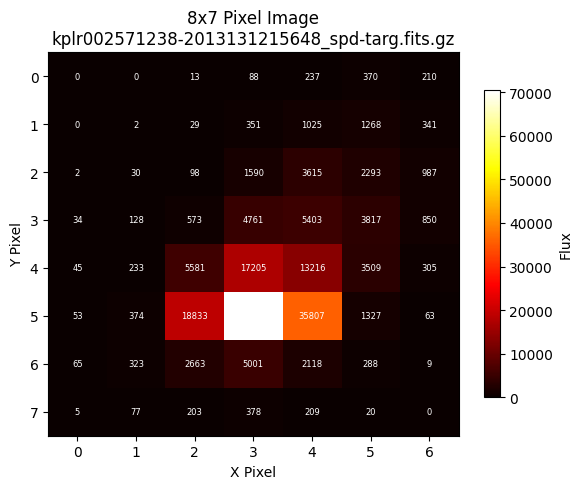

No SAP_FLUX, using sum of pixels


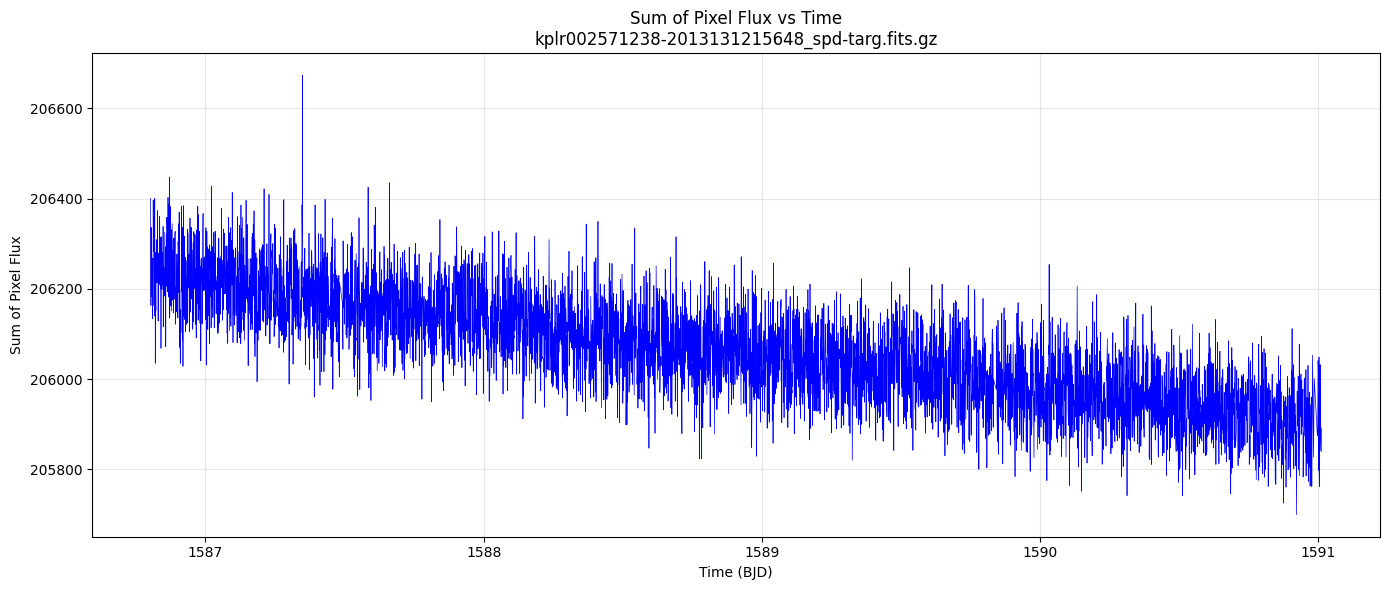

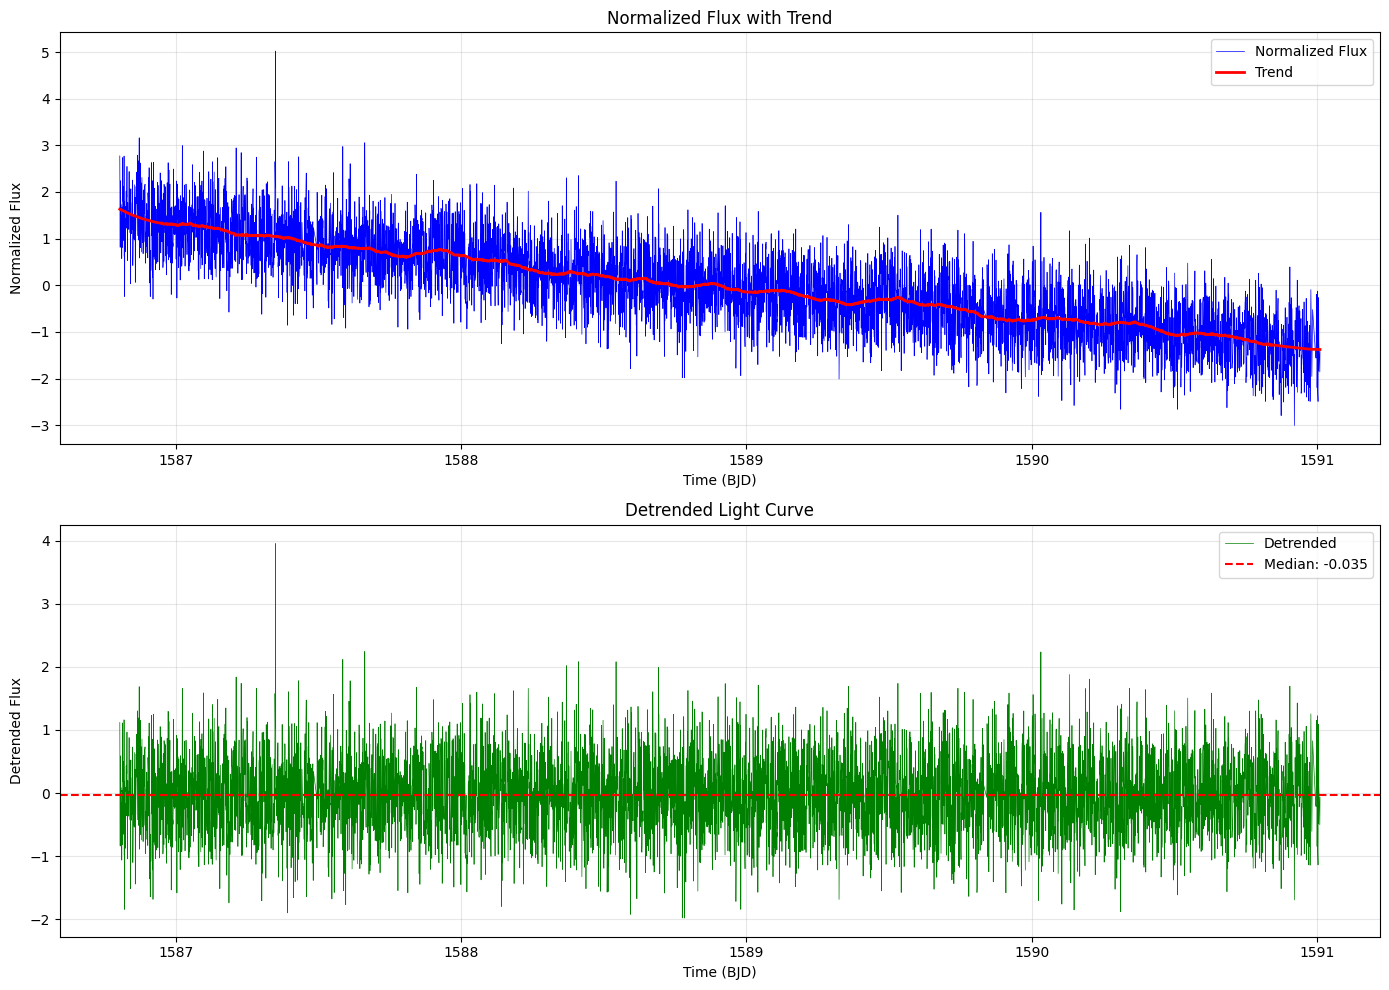

8x7 Pixel Image (First frame):


│      0      0     13     88    237    370    210 │
│      0      2     29    351   1025   1268    341 │
│      2     30     98   1590   3615   2293    987 │
│     34    128    573   4761   5403   3817    850 │
│     45    233   5581  17205  13216   3509    305 │
│     53    374  18833  70370  35807   1327     63 │
│     65    323   2663   5001   2118    288      9 │
│      5     77    203    378    209     20      0 │


Classification Options:
1 = Positive transit
2 = Negative transit
3 = Uncertain transit
4 = Skip this dataset
5 = Exit program (stop processing)


Enter your choice (1-5):  2


Marked as NEGATIVE.
Current Stats: Pos=1, Unc=0, Neg=4


Process next file? (yes/no):  y



Processing file 35/35: kplr003656476-2011116030358_spd-targ.fits.gz
Available columns: ['time', 'timecorr', 'cadenceno', 'raw_cnts', 'flux', 'flux_err', 'flux_bkg', 'flux_bkg_err', 'cosmic_rays', 'quality', 'pos_corr1', 'pos_corr2', 'rb_level']
Original shape: (53460, 11, 11)
Resized shape: (53460, 8, 7)
SAP_FLUX not available
Filtered by quality: 46457 good points out of 53460
Generating visualizations...


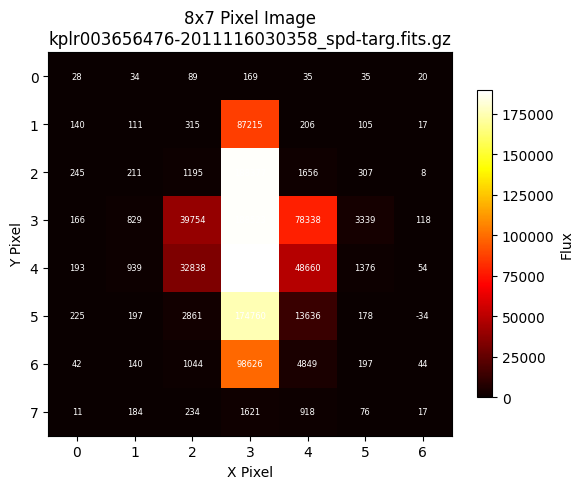

No SAP_FLUX, using sum of pixels


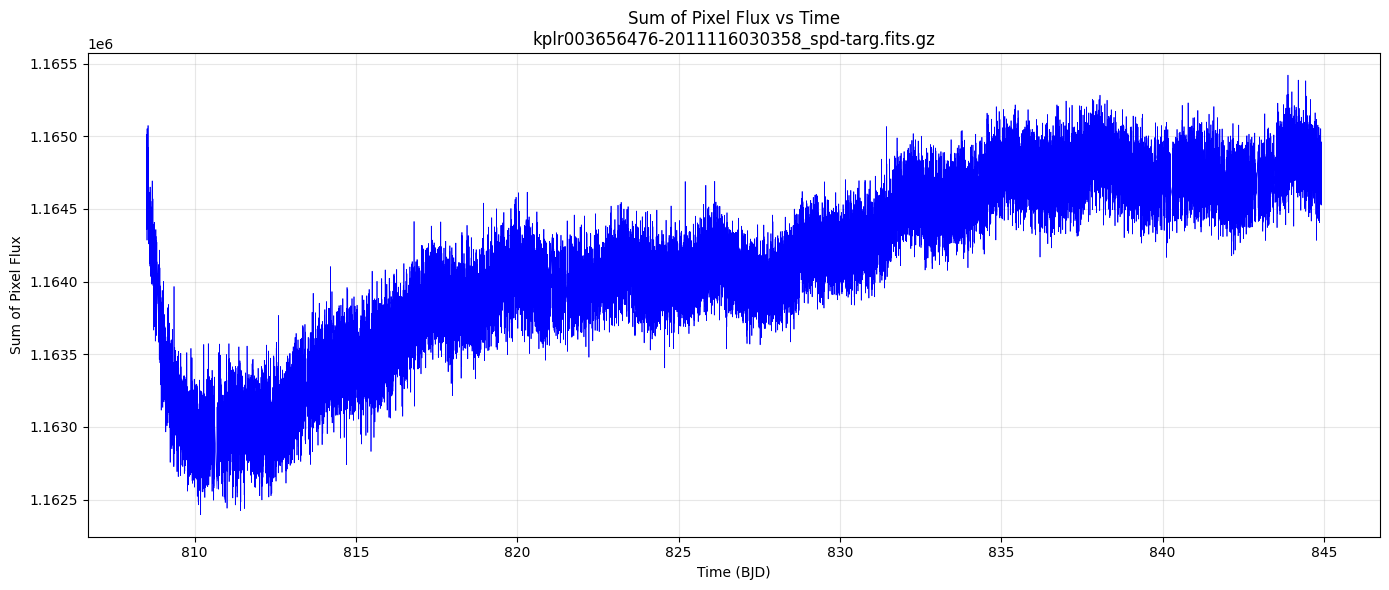

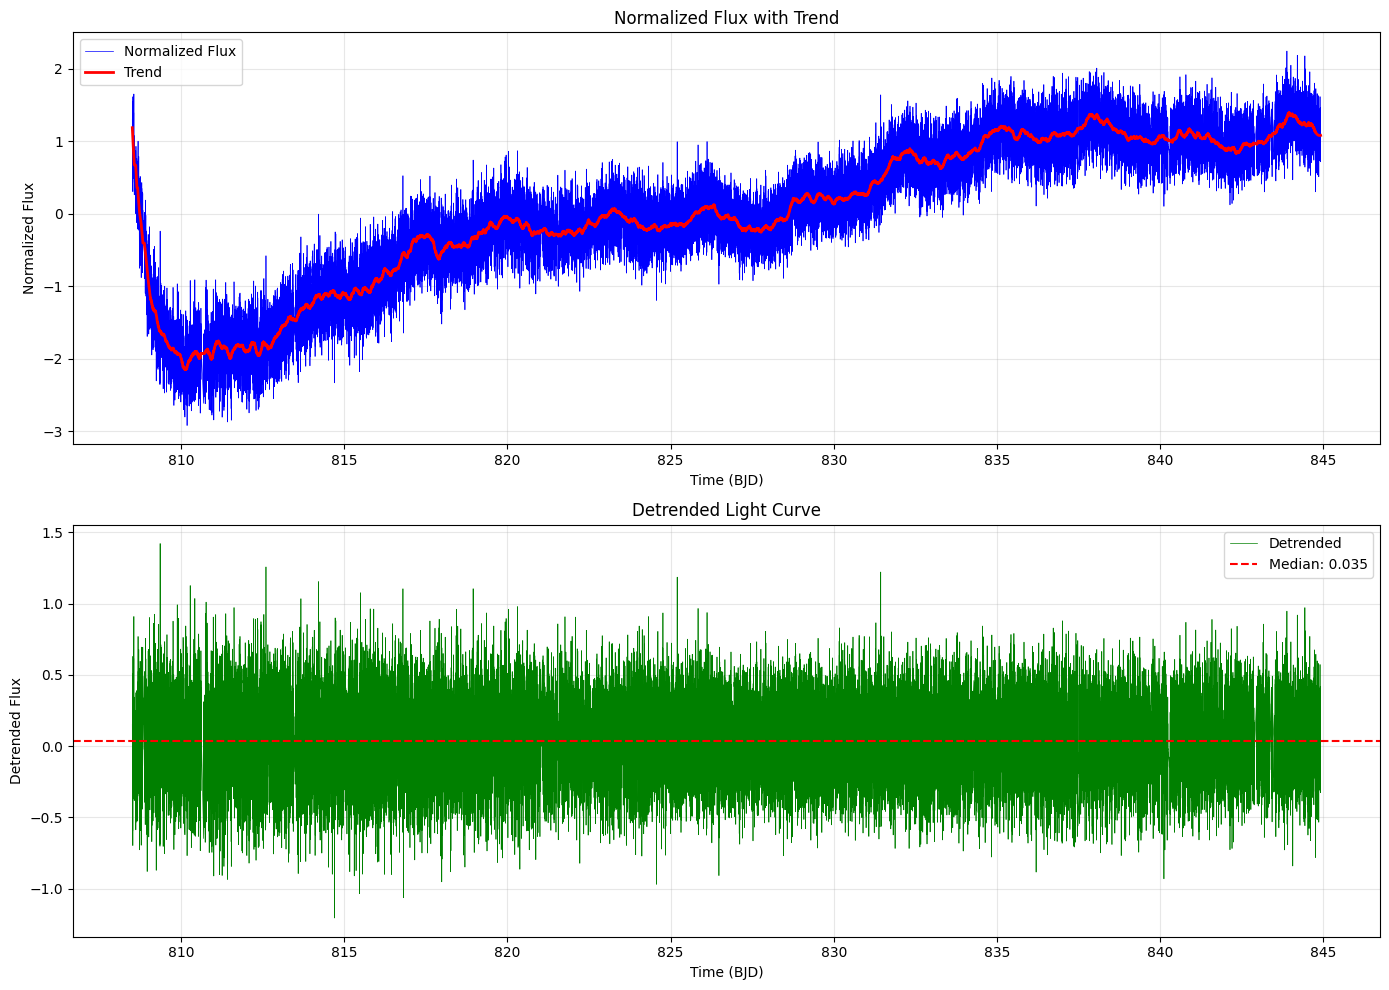

8x7 Pixel Image (First frame):


│     28     34     89    169     35     35     20 │
│    140    111    315  87215    206    105     17 │
│    245    211   1195 188377   1656    307      8 │
│    166    829  39754 188523  78338   3339    118 │
│    193    939  32838 189401  48660   1376     54 │
│    225    197   2861 174760  13636    178    -34 │
│     42    140   1044  98626   4849    197     44 │
│     11    184    234   1621    918     76     17 │


Classification Options:
1 = Positive transit
2 = Negative transit
3 = Uncertain transit
4 = Skip this dataset
5 = Exit program (stop processing)


Enter your choice (1-5):  2


Marked as NEGATIVE.
Current Stats: Pos=1, Unc=0, Neg=5
All files processed!
Final counts: Pos=1, Unc=0, Neg=5


In [9]:
if __name__ == "__main__":
    main()